## Outlier Detection & Handling

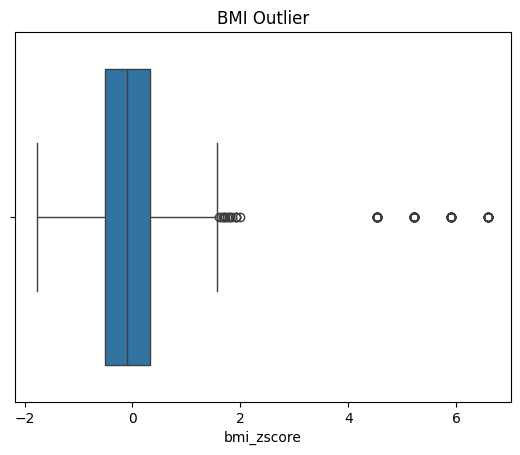

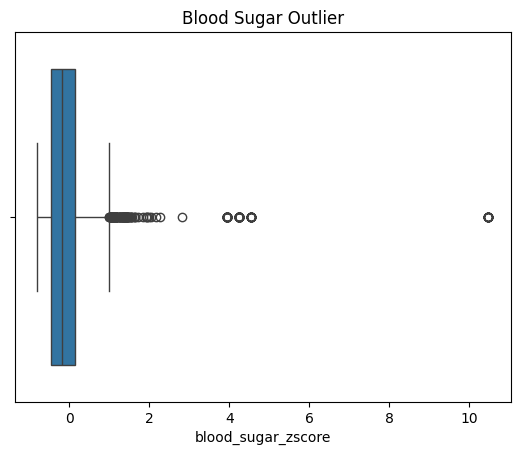

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

df_HCP = pd.read_csv('/content/healthcare_patient_dataset.csv')

#1
mean = df_HCP[['bmi','blood_sugar']].mean()
std = df_HCP[['bmi', 'blood_sugar']].std()

df_HCP['bmi_zscore']= (df_HCP['bmi'] - mean['bmi']) / std['bmi']
df_HCP['blood_sugar_zscore']= (df_HCP['blood_sugar'] - mean['blood_sugar']) / std['blood_sugar']

df_HCP['bmi_outlier'] = (df_HCP['bmi_zscore'] < -3) |  (df_HCP['bmi_zscore'] > 3)
df_HCP['BS_outlier_zscore'] = (df_HCP['blood_sugar_zscore'] < -3) |  (df_HCP['blood_sugar_zscore'] > 3)

sns.boxplot(x = df_HCP['bmi_zscore'])
plt.title('BMI Outlier')
plt.show()

sns.boxplot(x = df_HCP['blood_sugar_zscore'])
plt.title('Blood Sugar Outlier')
plt.show()


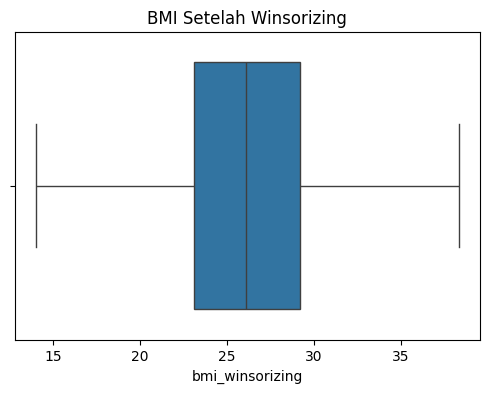

In [ ]:
#2
Q1 = df_HCP['bmi'].quantile(0.25)
Q3 = df_HCP['bmi'].quantile(0.75)
IQR = Q3 - Q1

upper_bound = Q3 + 1.5 * IQR
lower_bound = Q1 - 1.5 * IQR

df_HCP['bmi_outlier'] = (df_HCP['bmi'] < lower_bound) | (df_HCP['bmi'] > upper_bound)
df_HCP['bmi_winsorizing'] = df_HCP['bmi'].clip(
    lower=lower_bound,
    upper=upper_bound
)

plt.figure(figsize=(6,4))
sns.boxplot(x=df_HCP['bmi_winsorizing'])
plt.title('BMI Setelah Winsorizing')
plt.show()



In [ ]:
#3
# Saya memilih metode Z-Score dan IQR karena keduanya dinilai paling sesuai untuk menganalisis data kesehatan seperti BMI dan blood sugar. Metode Z-Score membantu melihat seberapa jauh nilai data menyimpang dari rata-rata. Sehingga cocok digunakan pada data yang memiliki distribusi normal. Sedangkan metode IQR lebih kuat terhadap data yang tidak berdistribusi normal karena menggunakan rentang kuartil untuk menentukan batas atas dan bawah dalam mendeteksi nilai ekstrem. Selain itu, proses winsorizing pada metode IQR tidak menghapus data, melainkan menyesuaikannya agar tetap berada dalam batas yang wajar. sehingga data tetap terjaga dan hasil analisis menjadi realistis dan akurat.

## Handling Missing Values


In [ ]:
#1
median = df_HCP['blood_pressure_sys'].median()
df_HCP['blood_pressure_sys_filled'] = df_HCP['blood_pressure_sys'].fillna(median)

df_HCP[['blood_pressure_sys','blood_pressure_sys_filled']].describe()

,blood_pressure_sys,blood_pressure_sys_filled
count,4950.000000,5500.000000
mean,122.188323,122.184491
std,15.981256,15.161002
min,80.000000,80.000000
25%,111.300000,112.600000
50%,122.150000,122.150000
75%,133.300000,131.825000
max,193.700000,193.700000


In [ ]:
#2
mode = df_HCP['smoker_status'].mode()[0]

df_HCP['smoker_status_filled'] = df_HCP['smoker_status'].fillna(mode)

print('-----Perbandingan Sebelum dan Sesudah Handling Missing Value-----')
print(df_HCP[['smoker_status','smoker_status_filled']].isna().sum())


-----Perbandingan Sebelum dan Sesudah Handling Missing Value-----
smoker_status           440
smoker_status_filled      0
dtype: int64


In [ ]:
# 3
# Kesalahan dalam imputasi data, misalnya salah mengisi status perokok, bisa memengaruhi hasil analisis kesehatan. Jika data tidak akurat, risiko penyakit yang dihitung bisa terlalu rendah atau tinggi, sehingga kesimpulan yang dibuat jadi menyesatkan. Hal ini bisa berdampak pada rekomendasi atau keputusan medis yang kurang tepat. Jadi, memastikan imputasi sesuai sangat penting supaya analisis tetap valid.

##Encoding Categorical Data1

In [ ]:
#1
ordinal_encoding = {'Low' : 1, 'Medium' : 2, 'High': 3}
df_HCP['diagnosis_risk_encoded'] = df_HCP['diagnosis_risk'].map(ordinal_encoding)

df_HCP[['diagnosis_risk','diagnosis_risk_encoded']]

,diagnosis_risk,diagnosis_risk_encoded
0,Medium,2
1,Low,1
2,Medium,2
3,Low,1
4,High,3
...,...,...
5495,Medium,2
5496,Low,1
5497,Medium,2
5498,Low,1


In [ ]:
#2
# binary encoding
column_bin = []
df_HCP['city_encoded'] = pd.factorize(df_HCP['city'])[0]
total_categories = df_HCP['city_encoded'].nunique()

bit = int(np.ceil(np.log2(total_categories)))

for i in range(bit):
  column_bin.append(f'bin_{i + 1}')

df_HCP[column_bin] = df_HCP['city_encoded'].apply(lambda x: list(f"{x:0{bit}b}")).apply(pd.Series).astype(int)

df_HCP[column_bin]

# frequency encoding

frequency = df_HCP['city'].value_counts()
df_HCP['city_frequency_encoded'] = df_HCP['city'].map(frequency)

df_HCP[['city', 'city_frequency_encoded']].head(20)

,city,city_frequency_encoded
0,Kota_073,46
1,Kota_001,73
2,Kota_005,38
3,Kota_057,66
4,Kota_064,231
5,Kota_037,43
6,Kota_010,102
7,Kota_084,176
8,Kota_042,93
9,Kota_047,20


In [ ]:
#3 Kalau pemilihan encoding di dataset medis salah dampaknya serius contohnya kalau kolom kategori seperti “status merokok” atau “golongan darah” dikodekan secara numerik tanpa memperhatikan makna, model bisa salah menganggap ada urutan atau jarak di antara kategori yang sebenarnya tidak ada. Akibatnya, prediksi menjadi bias atau tidak akurat, dan bisa menyesatkan analisis risiko pasien. Selain itu, performa model menurun karena informasi penting dari kategori tidak tersampaikan dengan benar.

##Scaling & Normalization


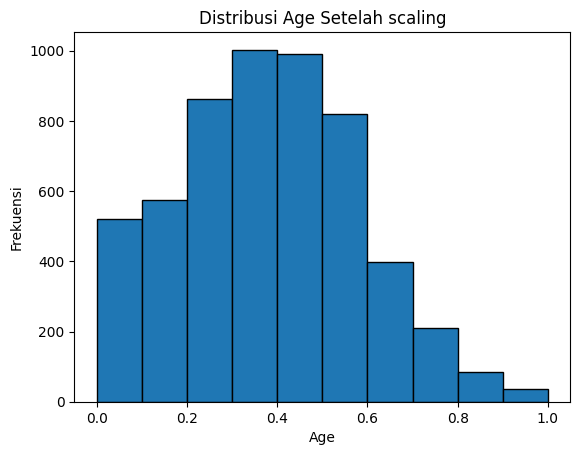

In [ ]:
#1
max = df_HCP['age'].max()
min = df_HCP['age'].min()

df_HCP['age_minmax'] = (df_HCP['age'] - min) / (max - min)
df_HCP[['age', 'age_minmax']]

plt.hist(df_HCP['age_minmax'], bins=10, edgecolor='k')
plt.title('Distribusi Age Setelah scaling')
plt.xlabel('Age')
plt.ylabel('Frekuensi')
plt.show()


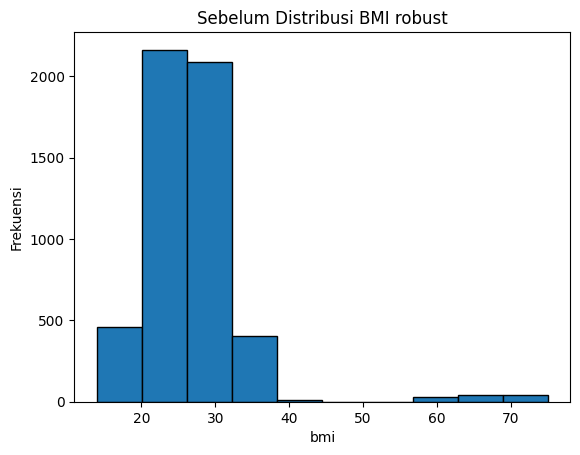

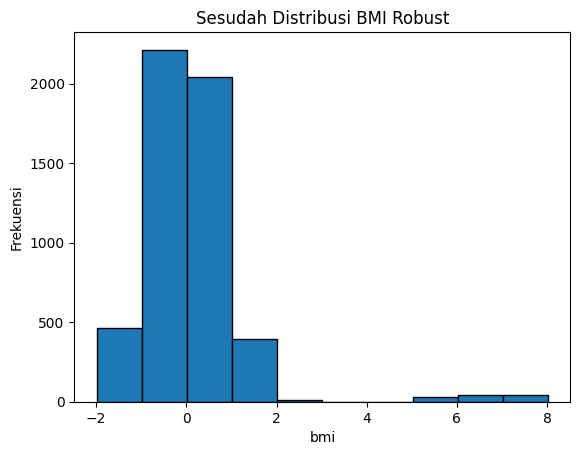

In [ ]:
#2
median = df_HCP['bmi'].median()
Q1 = df_HCP['bmi'].quantile(0.25)
Q3 = df_HCP['bmi'].quantile(0.75)
IQR = Q3 - Q1
df_HCP['bmi_robust'] = (df_HCP['bmi'] - median) / IQR

df_HCP[['bmi', 'bmi_robust']]

plt.hist(df_HCP['bmi'], bins=10, edgecolor='k')
plt.title('Sebelum Distribusi BMI robust')
plt.xlabel('bmi')
plt.ylabel('Frekuensi')
plt.show()

plt.hist(df_HCP['bmi_robust'], bins=10, edgecolor='k')
plt.title('Sesudah Distribusi BMI Robust')
plt.xlabel('bmi')
plt.ylabel('Frekuensi')
plt.show()

In [ ]:
#3
#Scaling penting dalam model prediksi risiko pasien karena banyak algoritma machine learning sensitif terhadap skala fitur. Misalnya, tinggi badan, berat badan, dan kadar gula darah memiliki satuan dan rentang yang berbeda. Kalau tidak diskalakan, fitur dengan nilai besar bisa mendominasi perhitungan model, sementara fitur lain yang juga penting menjadi kurang berpengaruh.

##Distribution Transformation


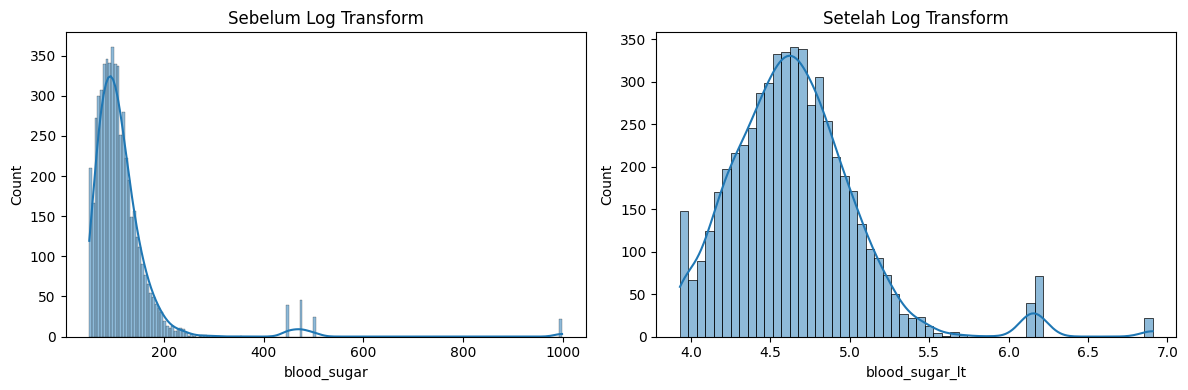

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_HCP['blood_sugar'], kde=True)
plt.title('Sebelum Log Transform')

df_HCP['blood_sugar_lt'] = np.log1p(df_HCP['blood_sugar'])

plt.subplot(1, 2, 2)
sns.histplot(df_HCP['blood_sugar_lt'], kde=True)
plt.title('Setelah Log Transform')

plt.tight_layout()
plt.show()

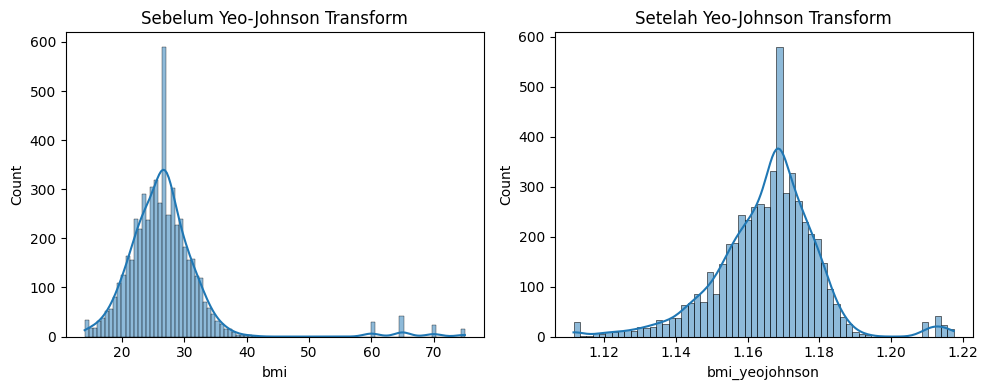

In [ ]:
#2
from scipy import stats

# wajib datanya tidak ada yang Nan
mean = df_HCP['bmi'].mean()
df_HCP['bmi'] = df_HCP['bmi'].fillna(mean)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(df_HCP['bmi'], kde=True)
plt.title('Sebelum Yeo-Johnson Transform')

df_HCP['bmi_yeojohnson'], _ = stats.yeojohnson(df_HCP['bmi'])

plt.subplot(1, 2, 2)
sns.histplot(df_HCP['bmi_yeojohnson'], kde=True)
plt.title('Setelah Yeo-Johnson Transform')

plt.tight_layout()
plt.show()

In [ ]:
#3
# Transformasi tidak boleh digunakan pada data klinis ketika makna nilai asli sangat penting untuk interpretasi medis. Misalnya, kadar gula darah, tekanan darah, atau skor risiko tertentu memiliki batas normal yang spesifik, jika diubah dengan log atau Yeo-Johnson, nilai aslinya menjadi sulit dipahami atau dibandingkan dengan standar klinis. Transformasi juga tidak cocok kalau data memiliki banyak nol atau negatif dan transformasi yang dipilih hanya bisa diterapkan pada nilai positif, karena bisa menimbulkan error atau hasil yang tidak valid.

##Imbalance Data

In [ ]:
#1
diagnosis_risk_max = df_HCP['diagnosis_risk'].value_counts().max()

df_majority = df_HCP[df_HCP['diagnosis_risk'] == 'Low']
df_manority_md = df_HCP[df_HCP['diagnosis_risk'] == 'Medium'].sample(diagnosis_risk_max, replace = True, random_state = 42)
df_manority_hg = df_HCP[df_HCP['diagnosis_risk'] == 'High'].sample(diagnosis_risk_max, replace = True, random_state = 42)

df_imbalance = pd.concat([df_majority,df_manority_md, df_manority_hg])

print('Sebelum Imbalance data dengan oversampling')
print(df_HCP['diagnosis_risk'].value_counts())
print('\n')
print('Setelah Imbalance data dengan oversampling')
print(df_imbalance['diagnosis_risk'].value_counts())


Sebelum Imbalance data dengan oversampling
diagnosis_risk
Low       2956
Medium    1983
High       561
Name: count, dtype: int64


Setelah Imbalance data dengan oversampling
diagnosis_risk
Low       2956
Medium    2956
High      2956
Name: count, dtype: int64


In [ ]:
from imblearn.over_sampling import SMOTE
df_HCP['diagnosis_risk_encoded']=  pd.factorize(df_HCP['diagnosis_risk'])[0]

X = df_HCP[['bmi', 'blood_sugar']]
y = df_HCP['diagnosis_risk_encoded']

print('Jumlah sampel sebelum SMOTE :')
print(y.value_counts())

smote = SMOTE(random_state = 42, k_neighbors = 5)
X_resampled, y_resampled = smote.fit_resample(X, y)

print('\n')
print("jumlah sampel setelah SMOTE :")
print(y_resampled.value_counts())

Jumlah sampel sebelum SMOTE :
diagnosis_risk_encoded
1    2956
0    1983
2     561
Name: count, dtype: int64


jumlah sampel setelah SMOTE :
diagnosis_risk_encoded
0    2956
1    2956
2    2956
Name: count, dtype: int64


In [ ]:
#3
# Risiko oversampling yang berlebihan pada data medis kalau kita membuat terlalu banyak data sintetis untuk kelas minoritas, model bisa terlalu menghafal pola buatan sehingga terlihat akurat di data latihan tapi gagal mengenali kasus nyata di dunia nyata (overfitting). Akibatnya, prediksi risiko pasien bisa salah, misalnya pasien berisiko tinggi dianggap aman atau sebaliknya. Selain itu, distribusi asli data bisa berubah, sehingga hubungan antara fitur dan outcome menjadi tidak representatif dari kondisi klinis yang sebenarnya.